# Complete Fitting Pipeline

This notebook demonstrates the full fitting pipeline:

1. **NLSQ** -- Fast point estimates with confidence intervals
2. **Bayesian NUTS** -- Full posterior via NumPyro with NLSQ warm-start
3. **Model comparison** -- Selecting between single and double exponential

## Prerequisites

- xpcsviewer installed
- For Bayesian fitting: `pip install numpyro jax arviz`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Generate Synthetic G2 Data

We create realistic synthetic data so this notebook is self-contained.

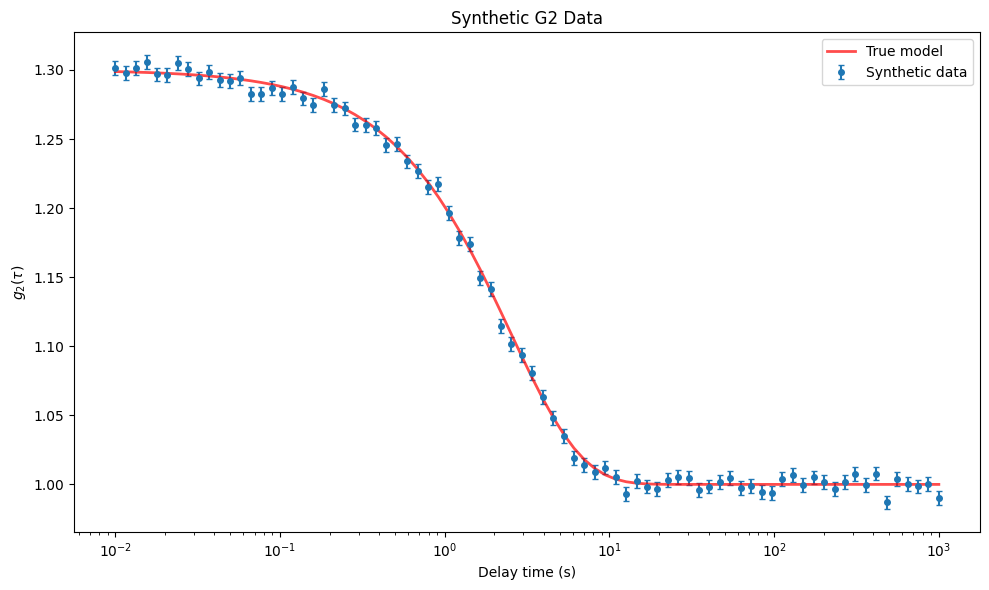

True parameters: tau=5.0, baseline=1.0, contrast=0.3


In [2]:
np.random.seed(42)

# True parameters
tau_true = 5.0
baseline_true = 1.0
contrast_true = 0.3

# Generate delay times (log-spaced, typical for XPCS)
t = np.logspace(-2, 3, 80)

# Generate G2 data with noise
g2_clean = baseline_true + contrast_true * np.exp(-2 * t / tau_true)
noise_level = 0.005
g2_noise = g2_clean + np.random.normal(0, noise_level, size=t.shape)
g2_err = np.full_like(t, noise_level)

# Plot
fig, ax = plt.subplots()
ax.errorbar(t, g2_noise, yerr=g2_err, fmt='o', ms=4, capsize=2, label='Synthetic data')
ax.plot(t, g2_clean, 'r-', linewidth=2, label='True model', alpha=0.7)
ax.set_xscale('log')
ax.set_xlabel('Delay time (s)')
ax.set_ylabel(r'$g_2(\tau)$')
ax.set_title('Synthetic G2 Data')
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

print(f"True parameters: tau={tau_true}, baseline={baseline_true}, contrast={contrast_true}")

## 2. NLSQ Fitting

The `nlsq_fit()` function uses NLSQ 0.6.0 for fast point estimates.

In [3]:
from xpcsviewer.fitting import nlsq_fit
from xpcsviewer.fitting.models import single_exp_func

nlsq_result = nlsq_fit(
    model_fn=single_exp_func,
    x=t,
    y=g2_noise,
    yerr=g2_err,
    p0={"tau": 1.0, "baseline": 1.0, "contrast": 0.3},
    bounds={
        "tau": (1e-6, 1e6),
        "baseline": (0.5, 2.0),
        "contrast": (0.0, 1.0),
    },
)

print(f"Converged: {nlsq_result.converged}")
print(f"\nFitted parameters:")
for name, val in nlsq_result.params.items():
    std = nlsq_result.get_param_uncertainty(name)
    print(f"  {name:>10} = {val:.6f} +/- {std:.6f}")

21:40:50.289 INFO     utils.logging_config | XPCS Viewer vunknown logging initialized
21:40:50.742 INFO     fileIO.hdf_reader    | HDF5ConnectionPool initialized: max_size=25, health_check_interval=180.0s


INFO:2026-02-23 21:40:52,889:jax._src.xla_bridge:810: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


21:40:52.889 INFO     jax._src.xla_bridge  | Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
21:40:53.065 INFO     plothandler.qt_signa | Configured PyQtGraph for Qt compatibility
21:40:53.107 INFO     utils.logging_config | === System Information ===
21:40:53.108 INFO     utils.logging_config | Platform: Linux-6.8.0-101-generic-x86_64-with-glibc2.39
21:40:53.108 INFO     utils.logging_config | Python: 3.13.7 (main, Sep 18 2025, 19:47:49) [Clang 20.1.4 ]
21:40:53.109 INFO     utils.logging_config | Working directory: /home/wei/Documents/GitHub/xpcsviewer/notebooks
21:40:53.109 INFO     utils.logging_config | Qt (via qtpy): 6.10.2
21:40:53.110 INFO     utils.logging_config | NumPy: 2.3.5
21:40:53.110 INFO     utils.logging_config | SciPy: 1.17.1
21:40:53.110 INFO     utils.logging_config | === End System Information ===
21:40:53.258 INFO     nlsq.core.minpack    | workflow='auto_global' starting

In [4]:
# Print the full summary
print(nlsq_result.summary())

NLSQ Fit Results
Status: Converged

Fit Quality:
  R²:            -52.130089
  Adjusted R²:   -54.227330
  RMSE:          9.419464e-01
  MAE:           7.547762e-01
  χ² (reduced):  0.9218

Model Selection:
  AIC:           -3.57
  BIC:           3.58

Parameters:
  tau: 4.913489e+00 ± 7.762066e-02
    95% CI: [4.761356e+00, 5.065623e+00]
  baseline: 1.000017e+00 ± 8.589400e-04
    95% CI: [9.983335e-01, 1.001701e+00]
  contrast: 2.995601e-01 ± 1.305356e-03
    95% CI: [2.970017e-01, 3.021186e-01]

Covariance: Valid


## 3. Visualize NLSQ Fit

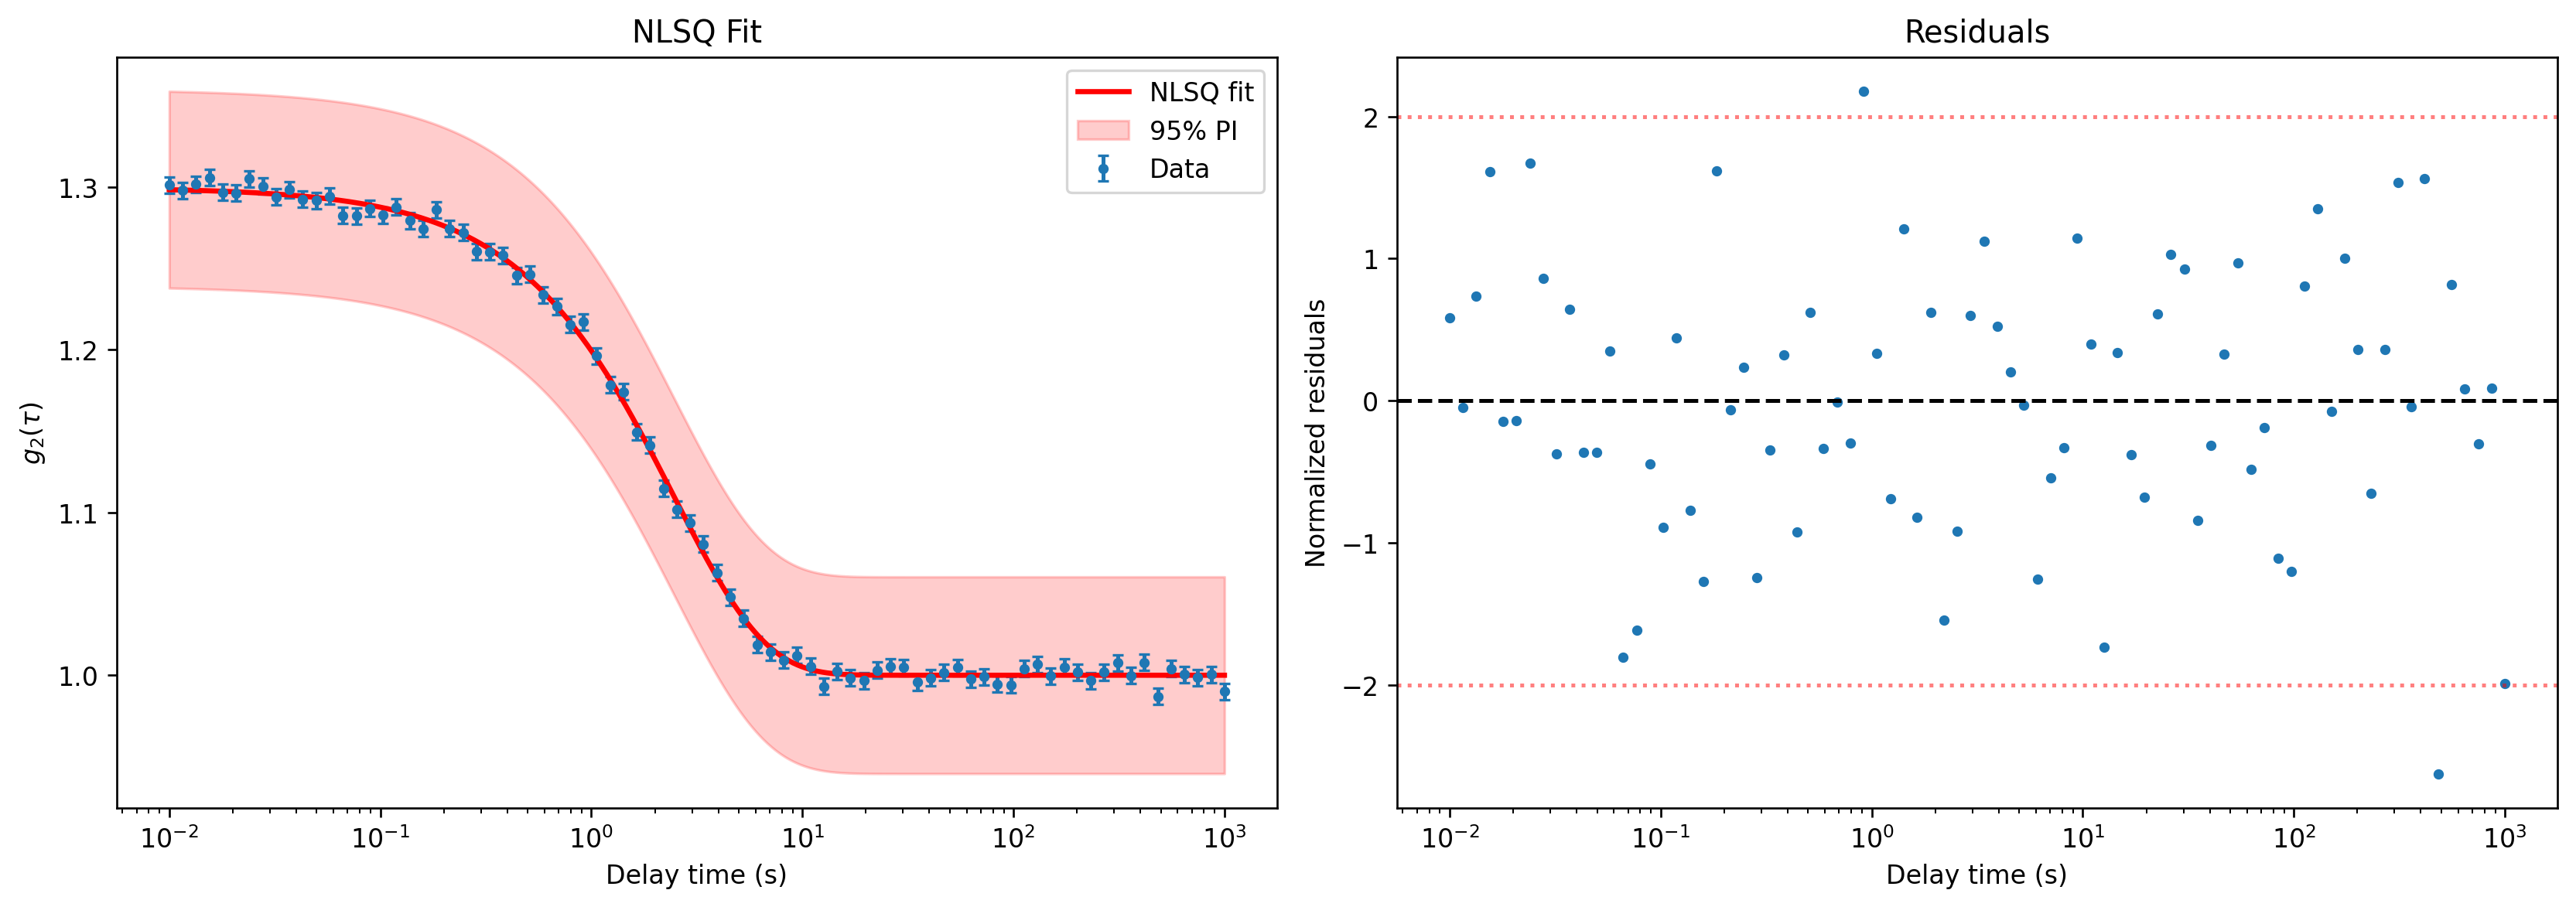

In [5]:
# Generate fit curve
t_fine = np.logspace(-2, 3, 500)
g2_fit = single_exp_func(
    t_fine,
    nlsq_result.params['tau'],
    nlsq_result.params['baseline'],
    nlsq_result.params['contrast'],
)

# Prediction intervals
pi_lower, pi_upper = nlsq_result.get_prediction_interval(t_fine)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fit plot
ax = axes[0]
ax.errorbar(t, g2_noise, yerr=g2_err, fmt='o', ms=3, capsize=2, label='Data')
ax.plot(t_fine, g2_fit, 'r-', linewidth=2, label='NLSQ fit')
if not np.any(np.isnan(pi_lower)):
    ax.fill_between(t_fine, pi_lower, pi_upper, alpha=0.2, color='red', label='95% PI')
ax.set_xscale('log')
ax.set_xlabel('Delay time (s)')
ax.set_ylabel(r'$g_2(\tau)$')
ax.set_title('NLSQ Fit')
ax.legend()

# Residuals
ax = axes[1]
g2_pred = single_exp_func(
    t, nlsq_result.params['tau'],
    nlsq_result.params['baseline'],
    nlsq_result.params['contrast'],
)
residuals = g2_noise - g2_pred
ax.plot(t, residuals / g2_err, 'o', ms=3)
ax.axhline(0, color='k', linestyle='--')
ax.axhline(2, color='r', linestyle=':', alpha=0.5)
ax.axhline(-2, color='r', linestyle=':', alpha=0.5)
ax.set_xscale('log')
ax.set_xlabel('Delay time (s)')
ax.set_ylabel('Normalized residuals')
ax.set_title('Residuals')

plt.tight_layout()
display(fig)
plt.close(fig)

## 4. Robust NLSQ Fitting

Use presets, stability checks, and diagnostics for difficult data.

In [6]:
robust_result = nlsq_fit(
    model_fn=single_exp_func,
    x=t, y=g2_noise, yerr=g2_err,
    p0={"tau": 1.0, "baseline": 1.0, "contrast": 0.3},
    bounds={"tau": (1e-6, 1e6), "baseline": (0.5, 2.0), "contrast": (0, 1)},
    workflow="auto_global",     # Global optimization workflow
    stability="auto",           # Automatic numerical fixes
    fallback=True,              # Fallback strategies
    compute_diagnostics=True,   # Model health diagnostics
)

print(f"Converged: {robust_result.converged}")
print(f"R-squared: {robust_result.r_squared:.6f}")

if robust_result.diagnostics is not None:
    print(f"Health score: {robust_result.health_score}/100")
    print(f"Is healthy: {robust_result.is_healthy}")
    print(f"Condition number: {robust_result.condition_number:.2f}")

21:41:02.358 INFO     nlsq.core.minpack    | workflow='auto_global' starting: n_points=80, n_params=3
21:41:02.360 INFO     nlsq.core.minpack    | workflow='auto_global' memory budget: available=46.1GB, threshold=34.6GB, peak_estimate=0.10GB
21:41:02.362 INFO     nlsq.core.minpack    | workflow='auto_global' memory strategy: STANDARD (peak 0.10GB fits in 34.6GB)
21:41:02.363 INFO     nlsq.global_optimiza | Scale ratio 1000000x suggests CMA-ES would be beneficial, but evosax not installed. Using multi-start. Install evosax with: pip install 'nlsq[global]'
21:41:02.365 INFO     nlsq.core.minpack    | workflow='auto_global' global method: Multi-Start (n_starts=10, scale_ratio=1000000.0)
21:41:02.372 INFO     nlsq.multi_start     | Generating 10 starting points using lhs n_starts=10 | sampler=lhs | center_on_p0=True
21:41:02.379 INFO     nlsq.multi_start     | Evaluating 10 starting points
21:41:02.379 INFO     nlsq.curve_fit       | Starting curve fit n_params=3 | n_data_points=80 | metho

## 5. Bayesian Fitting (NumPyro NUTS)

The `fit_single_exp()` function runs NLSQ warm-start followed by NumPyro NUTS.

**Note:** This requires NumPyro and JAX to be installed.

In [7]:
try:
    from xpcsviewer.fitting import fit_single_exp

    bayes_result = fit_single_exp(
        x=t,
        y=g2_noise,
        yerr=g2_err,
        num_warmup=500,
        num_samples=1000,
        num_chains=4,
        random_seed=42,
    )

    print("Bayesian Posterior Estimates:")
    for param in ['tau', 'baseline', 'contrast']:
        mean = bayes_result.get_mean(param)
        std = bayes_result.get_std(param)
        hdi_lo, hdi_hi = bayes_result.get_hdi(param)
        print(f"  {param:>10} = {mean:.4f} +/- {std:.4f}  "
              f"94% HDI: [{hdi_lo:.4f}, {hdi_hi:.4f}]")

    print(f"\nNLSQ warm-start: {bayes_result.nlsq_init}")

    # Diagnostics (r_hat, ess_bulk, ess_tail are per-parameter dicts)
    diag = bayes_result.diagnostics
    print(f"\nConvergence Diagnostics:")
    print(f"  Converged:    {diag.converged}")
    print(f"  Divergences:  {diag.divergences}")
    if diag.bfmi is not None:
        print(f"  BFMI:         {diag.bfmi:.4f}")
    for param in ['tau', 'baseline', 'contrast']:
        rhat = diag.r_hat.get(param, float('nan'))
        ess_b = diag.ess_bulk.get(param, 0)
        ess_t = diag.ess_tail.get(param, 0)
        print(f"  {param:>10}:  R-hat={rhat:.4f}  ESS(bulk)={ess_b:>6.0f}  ESS(tail)={ess_t:>6.0f}")

    BAYES_AVAILABLE = True

except ImportError as e:
    print(f"Bayesian fitting requires NumPyro: {e}")
    print("Install with: pip install numpyro jax arviz")
    BAYES_AVAILABLE = False

21:41:05.506 INFO     arviz                | Found 'auto' as default backend, checking available backends
21:41:05.507 INFO     arviz                | Matplotlib is available, defining as default backend
21:41:05.514 INFO     arviz.preview        | arviz_base available, exposing its functions as part of arviz.preview
21:41:05.634 INFO     arviz.preview        | arviz_stats available, exposing its functions as part of arviz.preview
21:41:05.901 INFO     arviz.preview        | arviz_plots available, exposing its functions as part of arviz.preview
21:41:05.940 INFO     fitting.sampler      | Running NLSQ warm-start for single exponential fit
21:41:05.941 INFO     nlsq.core.minpack    | workflow='auto_global' starting: n_points=80, n_params=3
21:41:05.942 INFO     nlsq.core.minpack    | workflow='auto_global' memory budget: available=46.3GB, threshold=34.7GB, peak_estimate=0.10GB
21:41:05.943 INFO     nlsq.core.minpack    | workflow='auto_global' memory strategy: STANDARD (peak 0.10GB fits

sample: 100%|██████████| 1750/1750 [00:08<00:00, 211.13it/s, 15 steps of size 1.64e-01. acc. prob=0.93] 


Bayesian Posterior Estimates:
         tau = 4.9108 +/- 0.0755  94% HDI: [4.7732, 5.0508]
    baseline = 1.0000 +/- 0.0008  94% HDI: [0.9984, 1.0016]
    contrast = 0.2996 +/- 0.0013  94% HDI: [0.2972, 0.3020]

NLSQ warm-start: {'tau': np.float64(4.913489444489413), 'baseline': np.float64(1.0000170185807058), 'contrast': np.float64(0.29956010411142286)}

Convergence Diagnostics:
  Converged:    True
  Divergences:  0
  BFMI:         1.1066
         tau:  R-hat=1.0034  ESS(bulk)=  1693  ESS(tail)=  1632
    baseline:  R-hat=1.0019  ESS(bulk)=  2708  ESS(tail)=  2859
    contrast:  R-hat=1.0009  ESS(bulk)=  1858  ESS(tail)=  2060


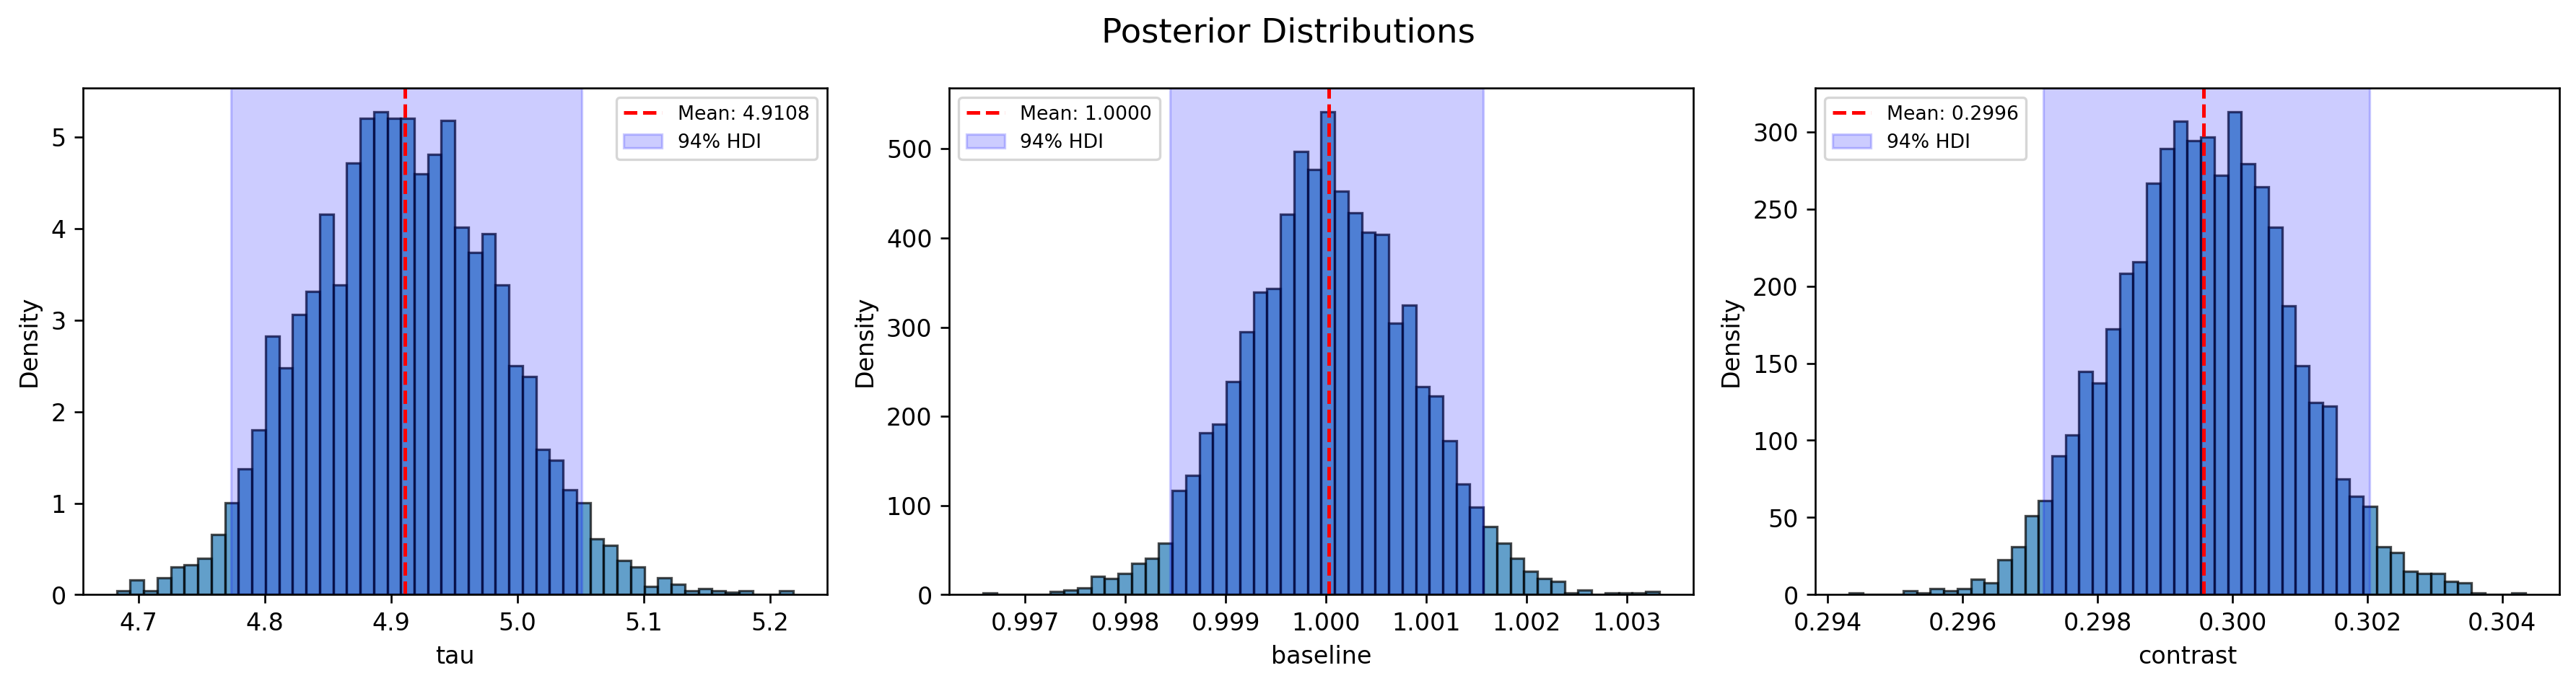

In [8]:
if BAYES_AVAILABLE:
    # Posterior distributions
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for i, param in enumerate(['tau', 'baseline', 'contrast']):
        samples = bayes_result.get_samples(param)
        axes[i].hist(samples, bins=50, density=True, alpha=0.7, edgecolor='black')
        axes[i].axvline(bayes_result.get_mean(param), color='r',
                        linestyle='--', label=f'Mean: {bayes_result.get_mean(param):.4f}')
        hdi_lo, hdi_hi = bayes_result.get_hdi(param)
        axes[i].axvspan(hdi_lo, hdi_hi, alpha=0.2, color='blue', label='94% HDI')
        axes[i].set_xlabel(param)
        axes[i].set_ylabel('Density')
        axes[i].legend(fontsize=8)

    plt.suptitle('Posterior Distributions', fontsize=14)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

### Bayesian Fit with 95% Credible Interval

We propagate posterior uncertainty to the model prediction by evaluating the
model at every posterior draw, then computing the 2.5th–97.5th percentile
envelope. This **posterior predictive band** shows the range of plausible
$g_2(\tau)$ curves given the data — a much richer picture than NLSQ point
estimates alone.

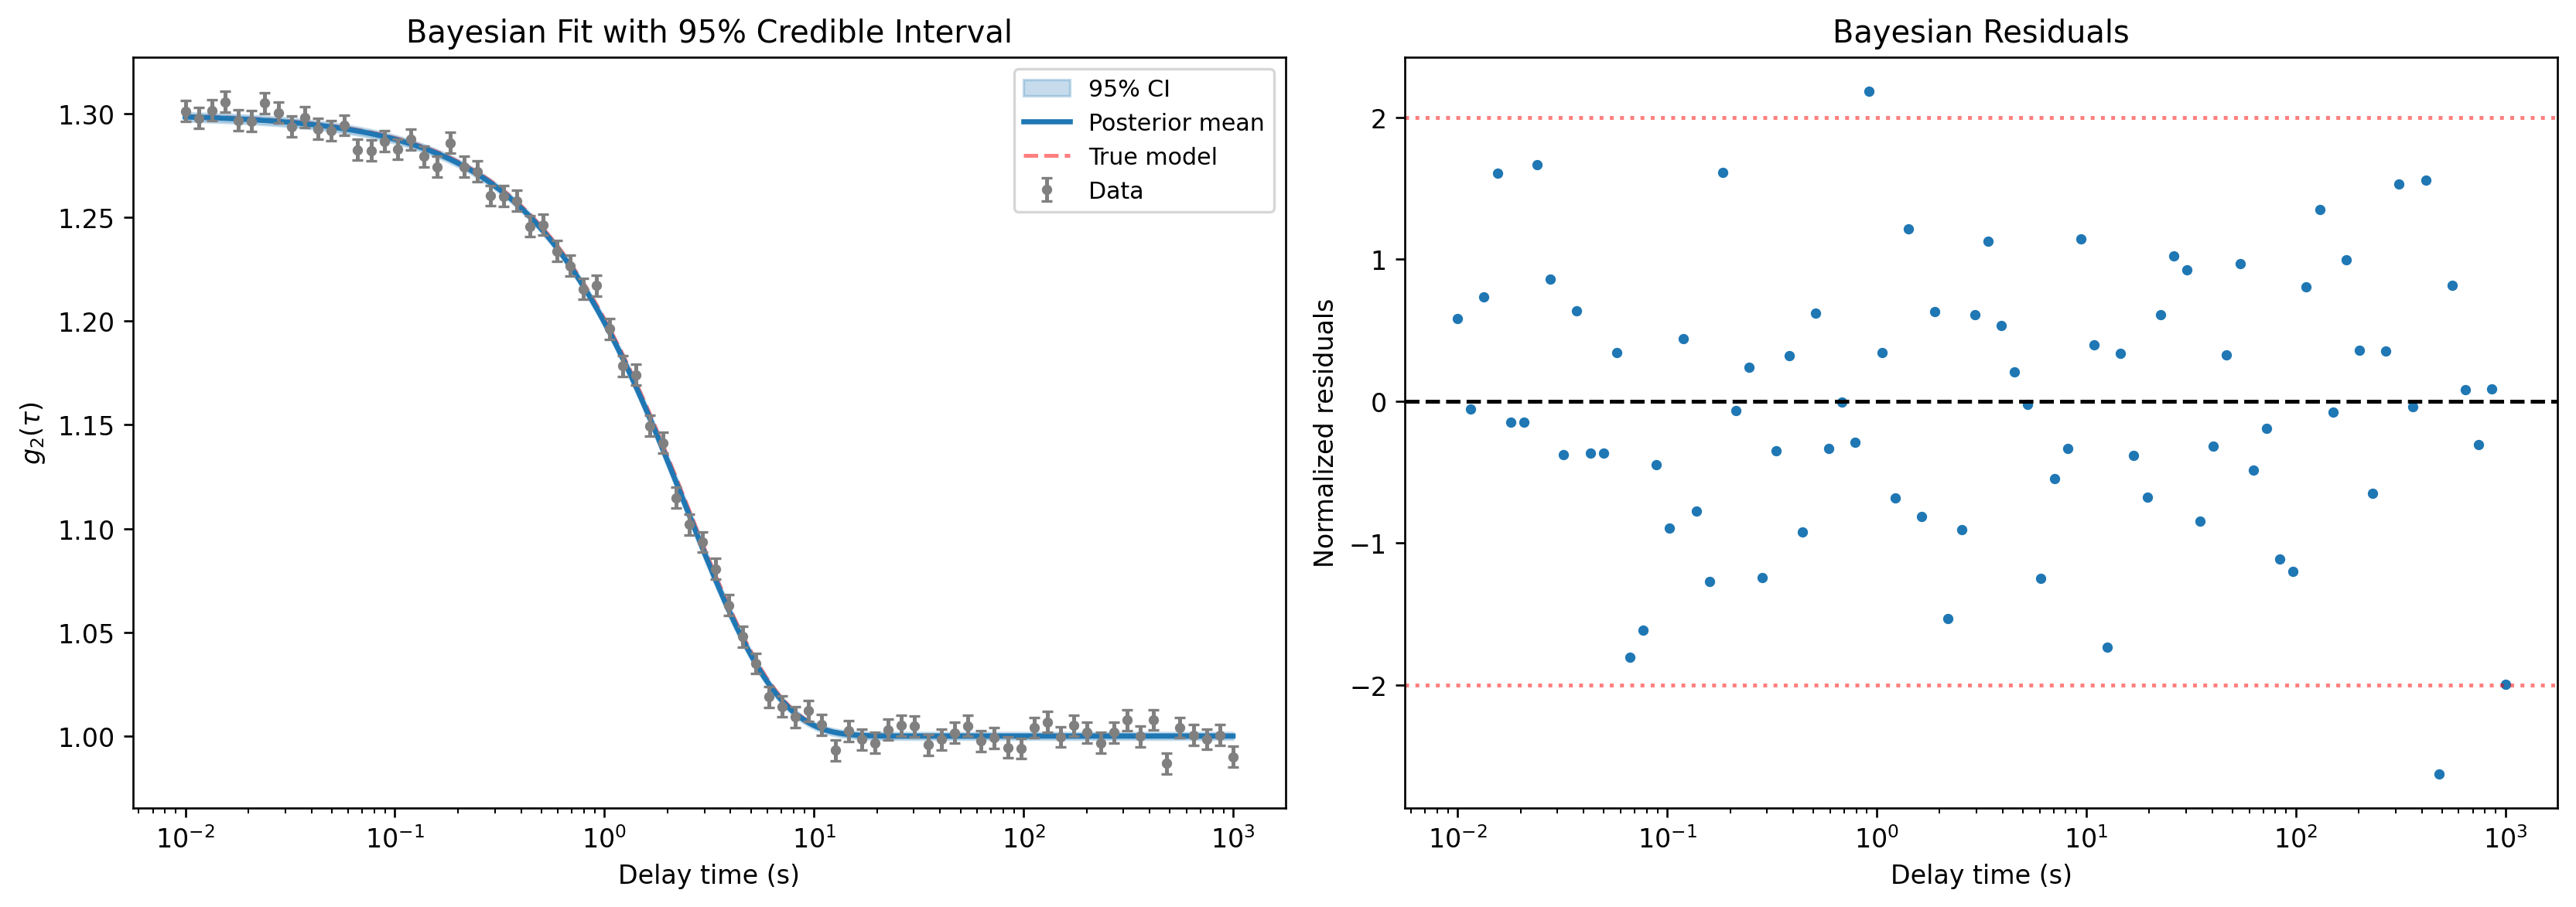

95% CI width statistics:
  Mean CI width: 0.003641
  Max  CI width: 0.005392 (at t=2.917 s)
  Min  CI width: 0.003012 (at t=9.682 s)


In [9]:
if BAYES_AVAILABLE:
    # Get posterior samples
    tau_samples = bayes_result.get_samples('tau')
    baseline_samples = bayes_result.get_samples('baseline')
    contrast_samples = bayes_result.get_samples('contrast')

    # Evaluate model at every posterior draw
    t_fine = np.logspace(-2, 3, 500)
    g2_draws = np.array([
        b + c * np.exp(-2 * t_fine / tau)
        for tau, b, c in zip(tau_samples, baseline_samples, contrast_samples)
    ])

    # Posterior mean and 95% credible interval
    g2_mean = np.mean(g2_draws, axis=0)
    g2_lo = np.percentile(g2_draws, 2.5, axis=0)
    g2_hi = np.percentile(g2_draws, 97.5, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Fit + 95% CI
    ax = axes[0]
    ax.fill_between(t_fine, g2_lo, g2_hi, alpha=0.25, color='#1f77b4',
                    label='95% CI')
    ax.errorbar(t, g2_noise, yerr=g2_err, fmt='o', ms=3, capsize=2,
                color='gray', label='Data', zorder=3)
    ax.plot(t_fine, g2_mean, '-', linewidth=2, color='#1f77b4',
            label='Posterior mean', zorder=2)
    ax.plot(t, g2_clean, 'r--', linewidth=1.5, alpha=0.5,
            label='True model', zorder=1)
    ax.set_xscale('log')
    ax.set_xlabel('Delay time (s)')
    ax.set_ylabel(r'$g_2(\tau)$')
    ax.set_title('Bayesian Fit with 95% Credible Interval')
    ax.legend(fontsize=9)

    # Right: Residuals
    ax = axes[1]
    g2_pred_mean = np.interp(t, t_fine, g2_mean)
    residuals = g2_noise - g2_pred_mean
    ax.plot(t, residuals / g2_err, 'o', ms=3, color='#1f77b4')
    ax.axhline(0, color='k', linestyle='--')
    ax.axhline(2, color='r', linestyle=':', alpha=0.5)
    ax.axhline(-2, color='r', linestyle=':', alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('Delay time (s)')
    ax.set_ylabel('Normalized residuals')
    ax.set_title('Bayesian Residuals')

    plt.tight_layout()
    display(fig)
    plt.close(fig)

    # Print CI width at key time points
    ci_width = g2_hi - g2_lo
    print(f'95% CI width statistics:')
    print(f'  Mean CI width: {np.mean(ci_width):.6f}')
    print(f'  Max  CI width: {np.max(ci_width):.6f} (at t={t_fine[np.argmax(ci_width)]:.3f} s)')
    print(f'  Min  CI width: {np.min(ci_width):.6f} (at t={t_fine[np.argmin(ci_width)]:.3f} s)')

## 6. ArviZ Diagnostics

Six publication-quality diagnostic plots assess MCMC convergence and sampling quality.

| Plot | Purpose | Good Result | Bad Result | Fix |
|------|---------|-------------|------------|-----|
| **Trace** | Visualize sampling | Fuzzy caterpillar | Trends, jumps | Increase warmup |
| **Pair** | Correlations, divergences | Elliptical, no divergences | Funnel, many divergences | Better priors, reparameterize |
| **Forest** | Credible intervals | Narrow intervals | Very wide | More data, tighter priors |
| **Autocorr** | Mixing quality | Fast decay to 0 | Slow decay | More samples |
| **Rank** | Convergence | Uniform histogram | Non-uniform | More warmup |
| **ESS** | Sample efficiency | ESS > 400 | ESS < 100 | More samples, check mixing |

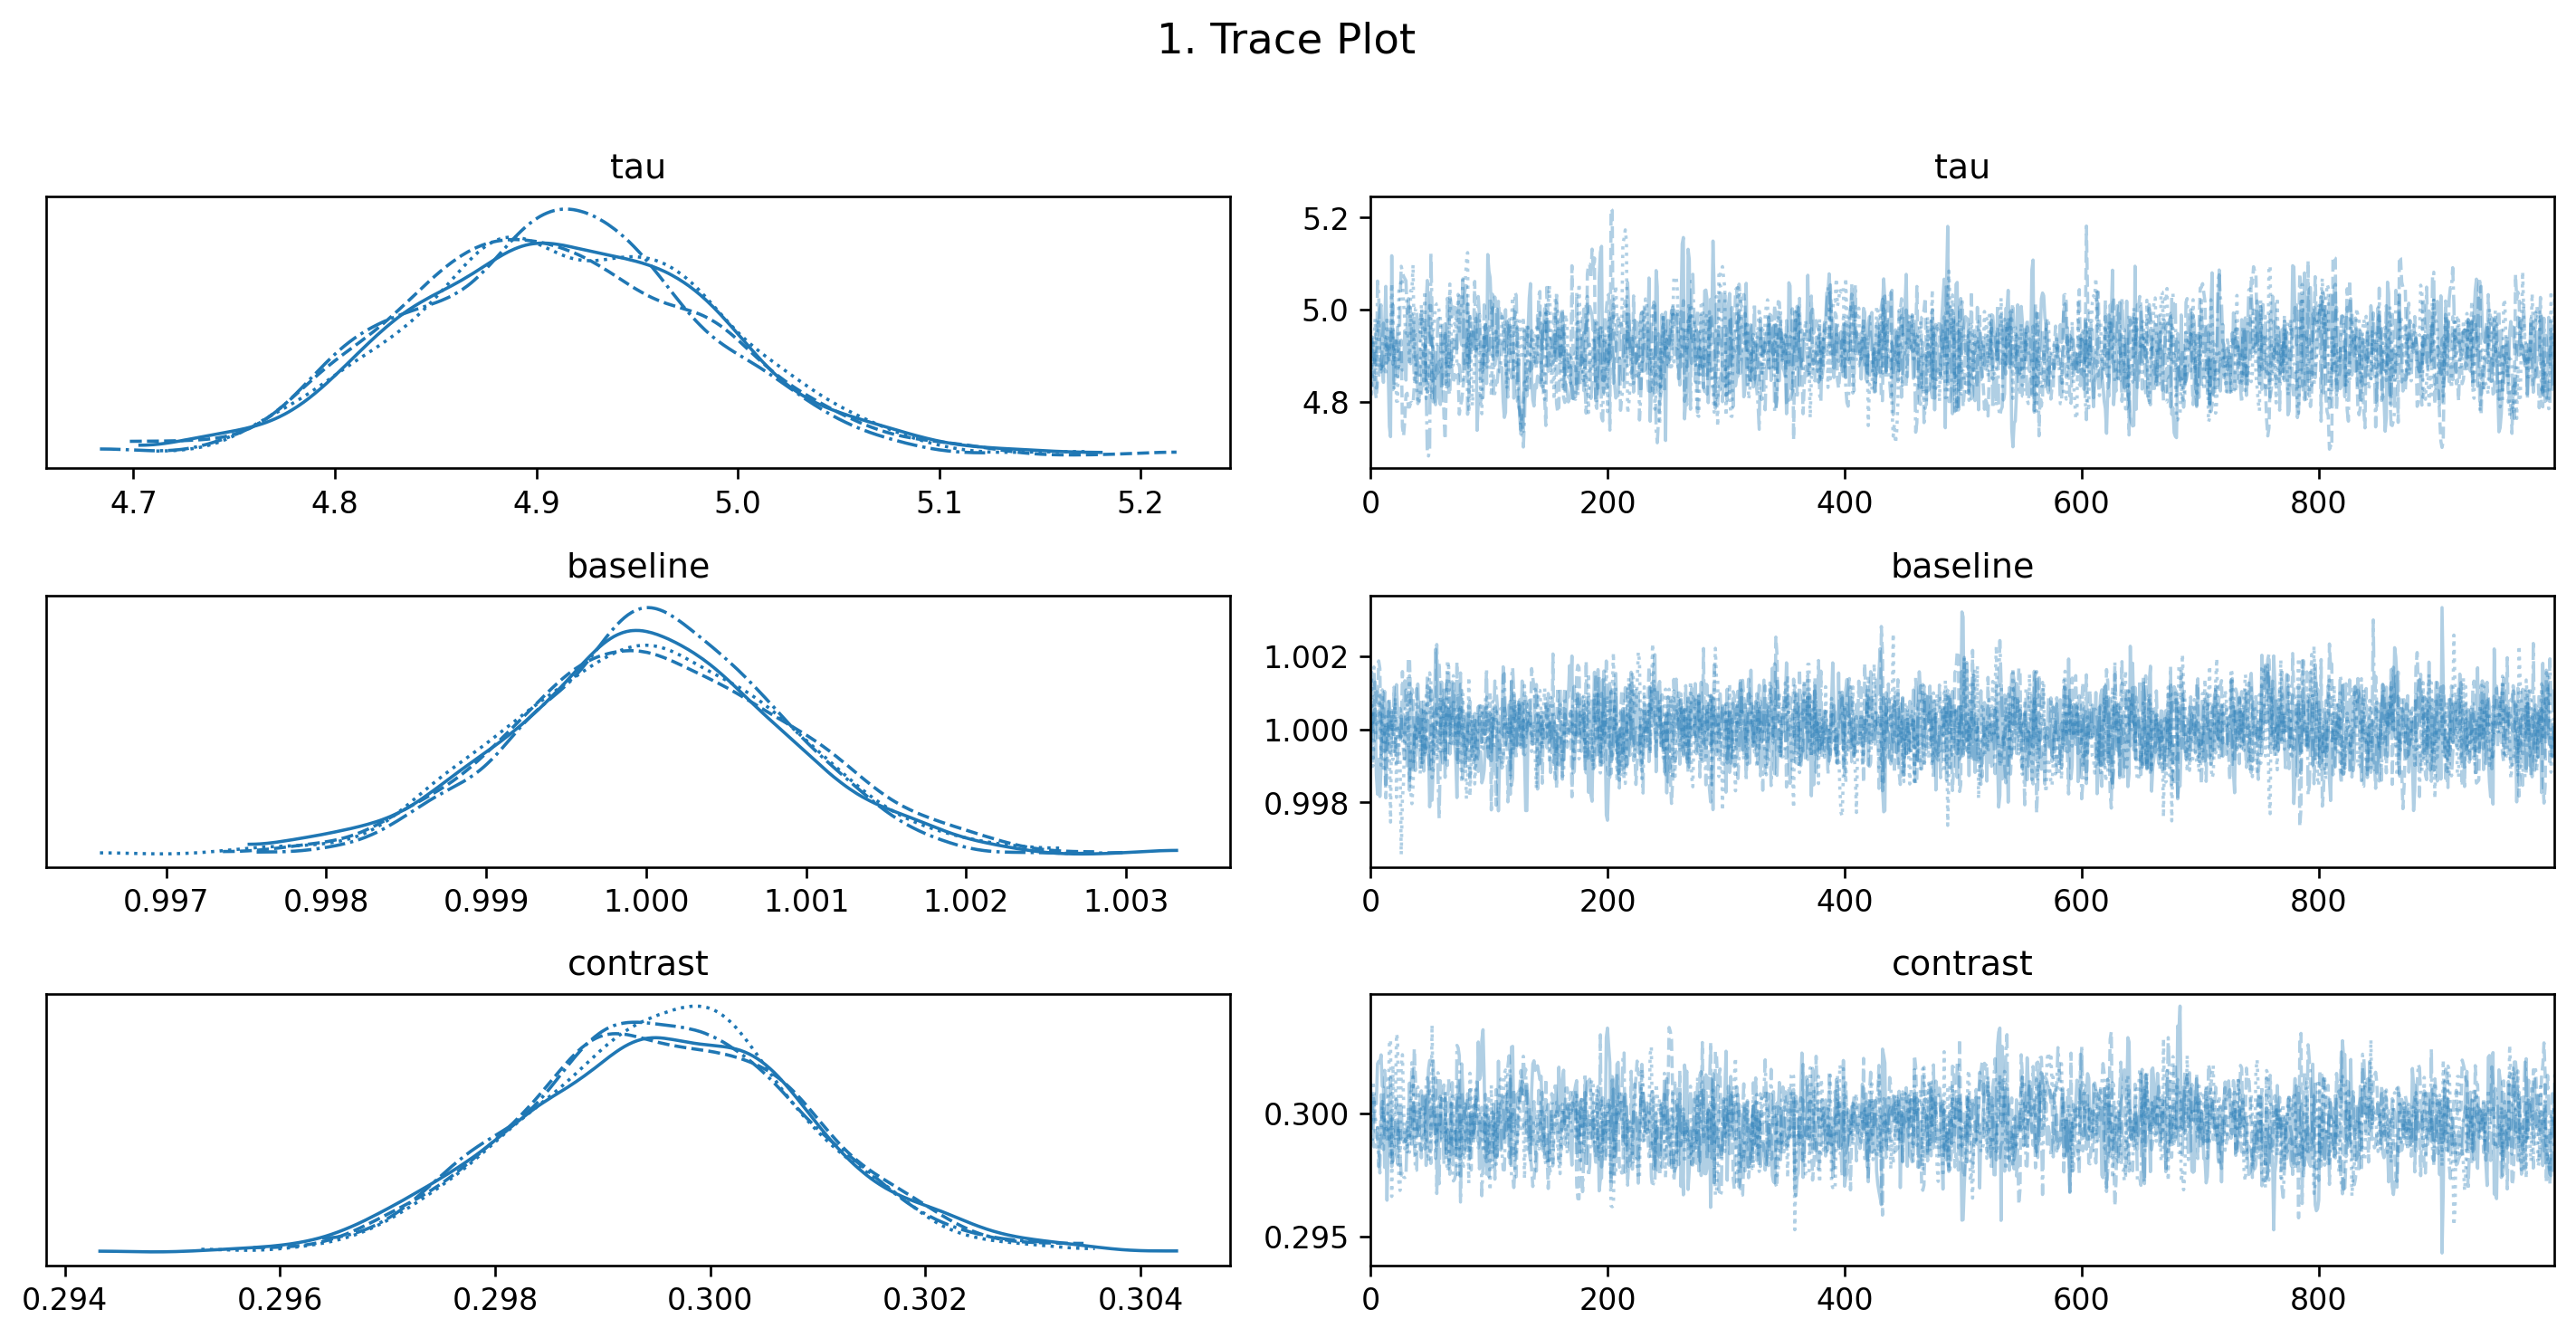

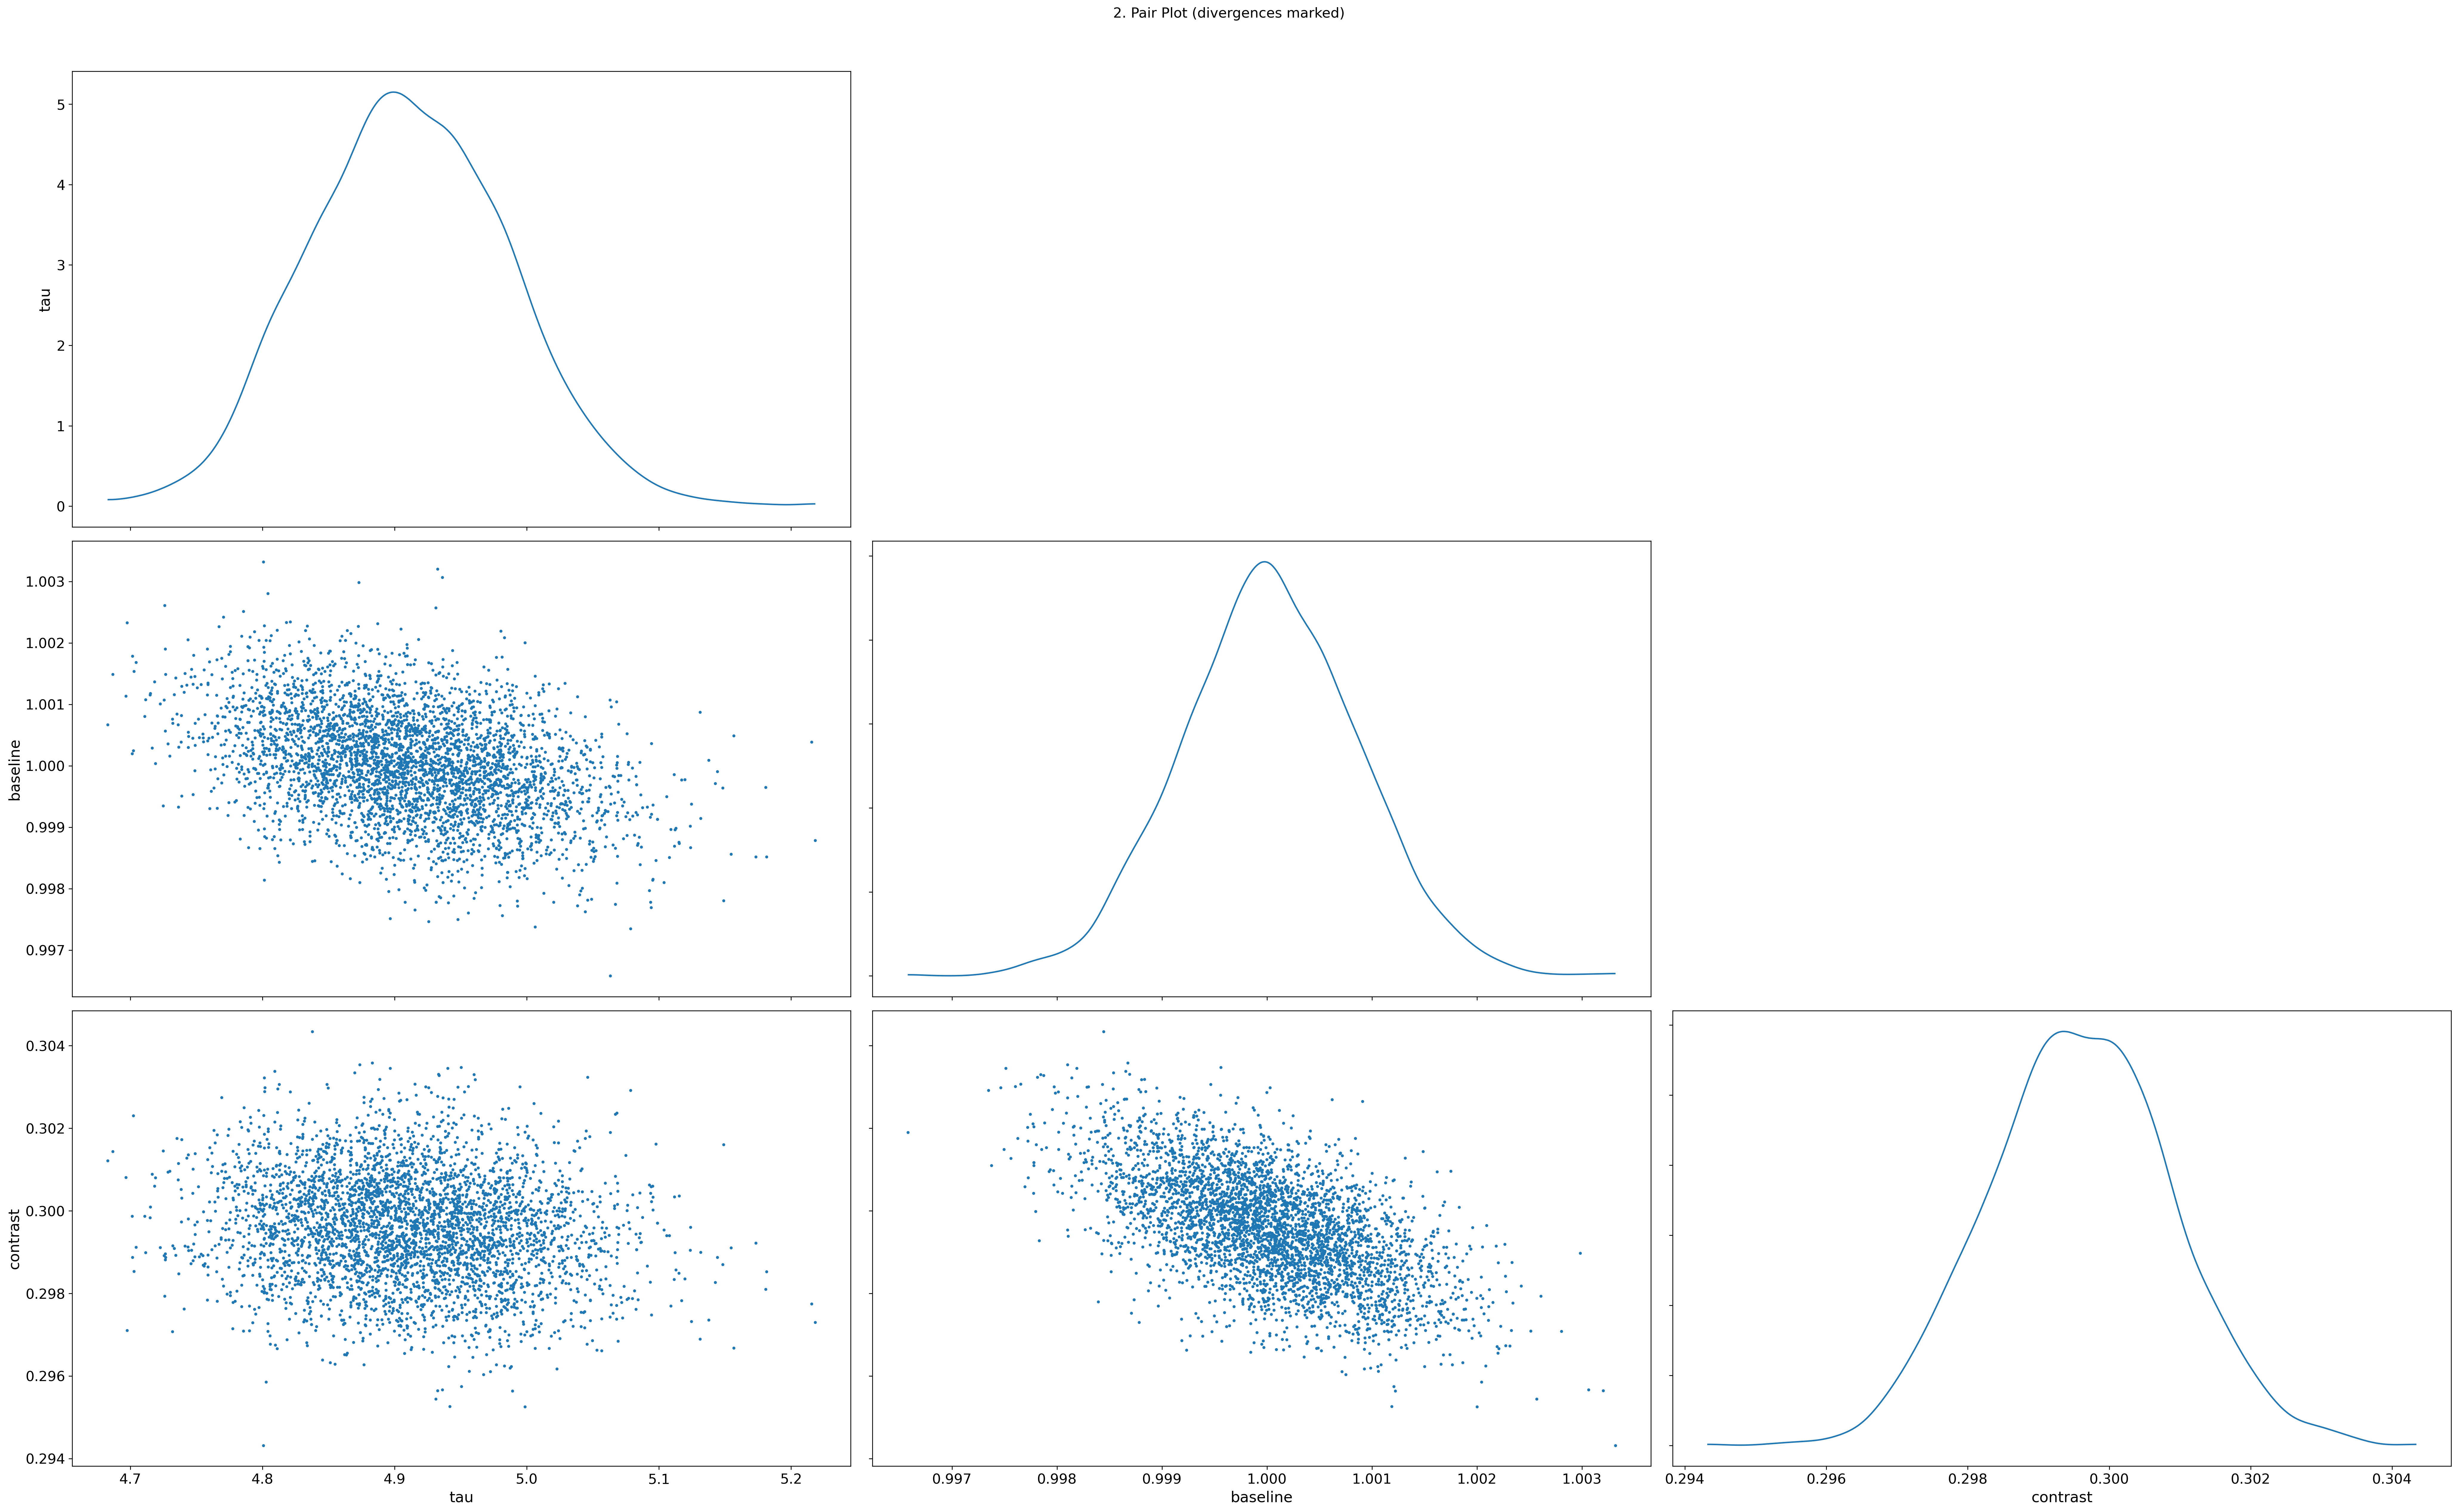

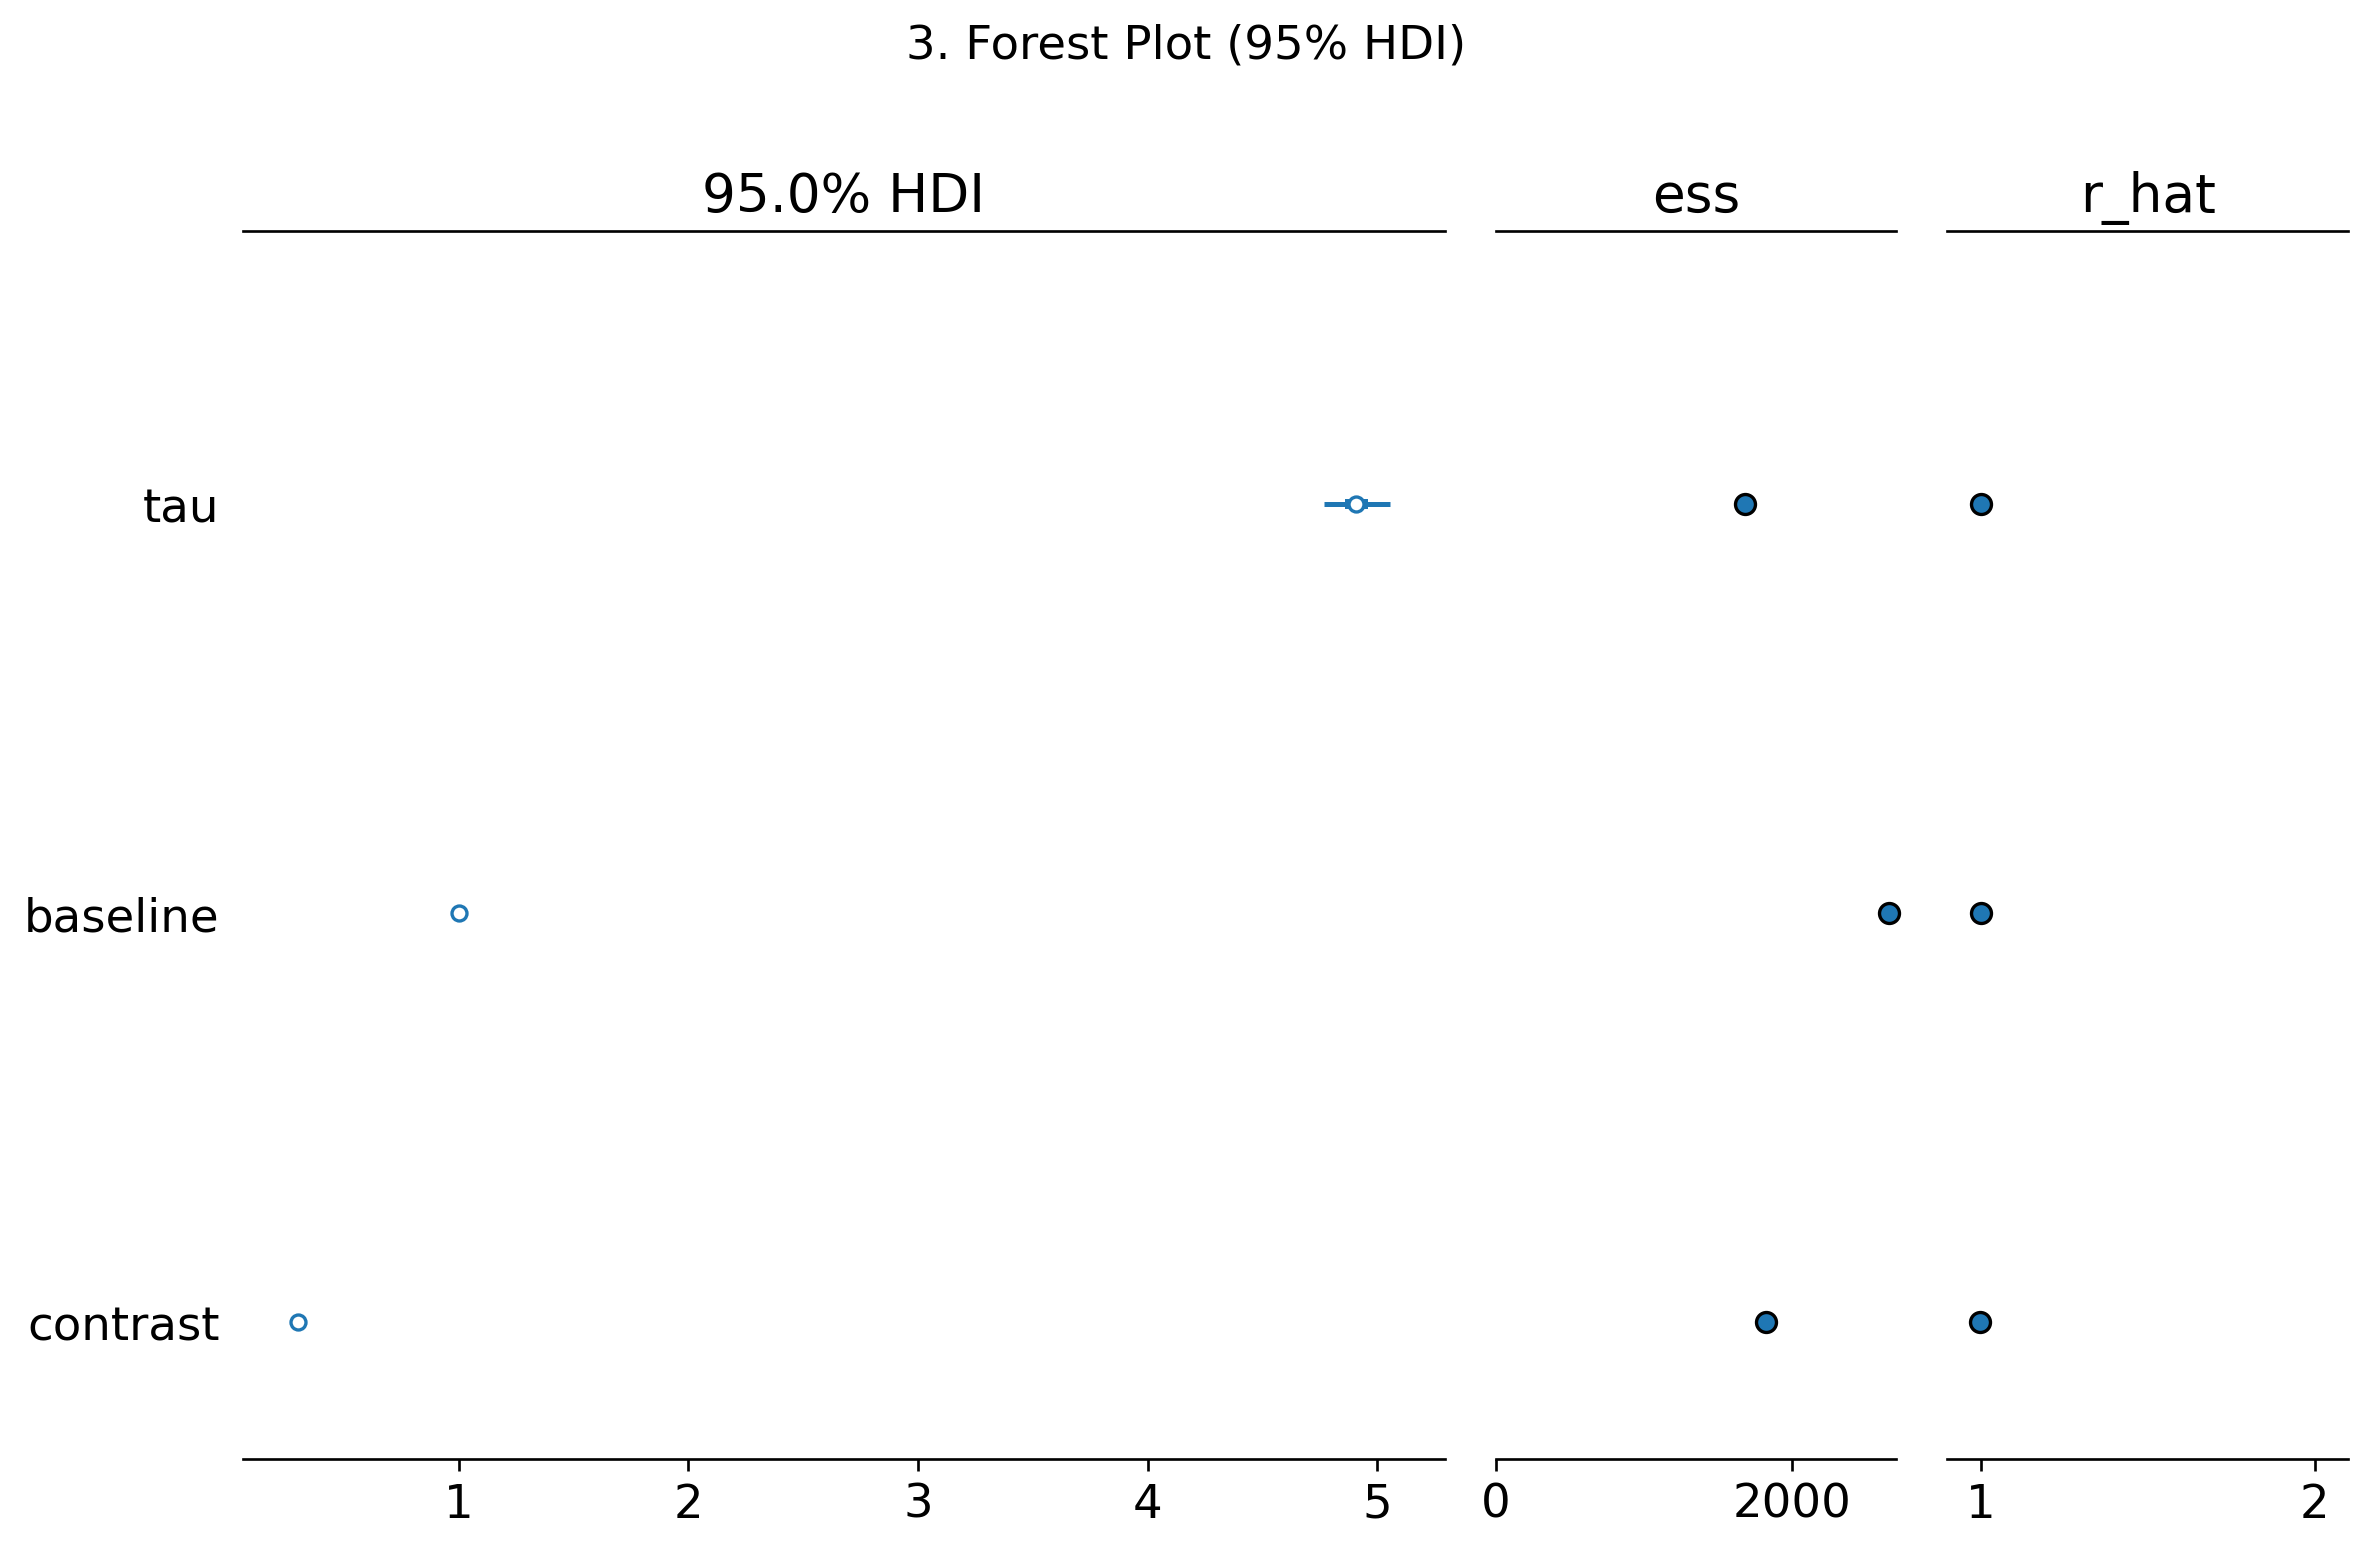

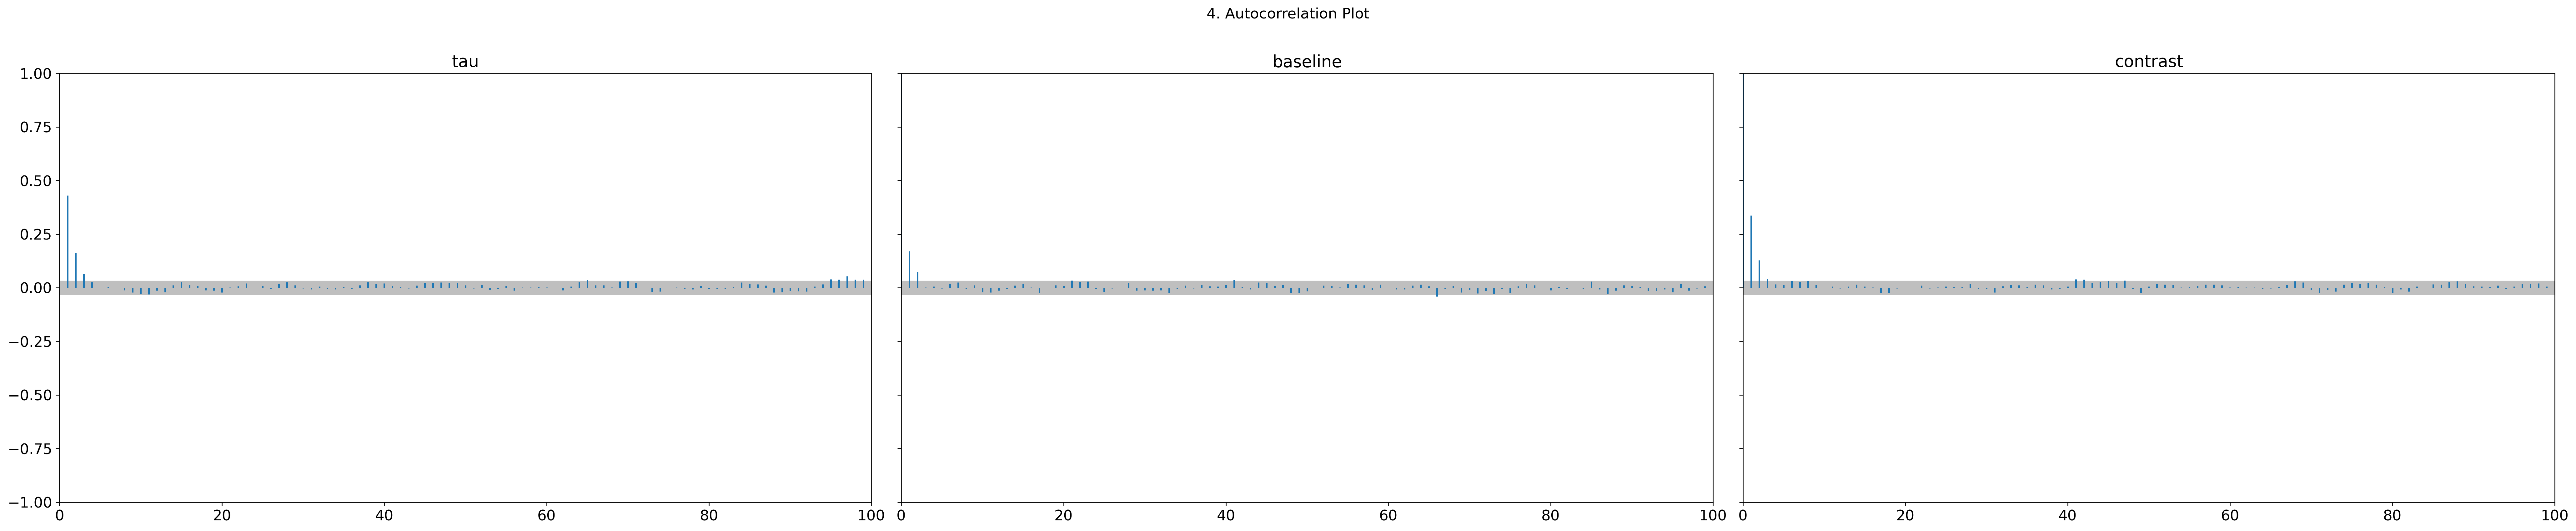

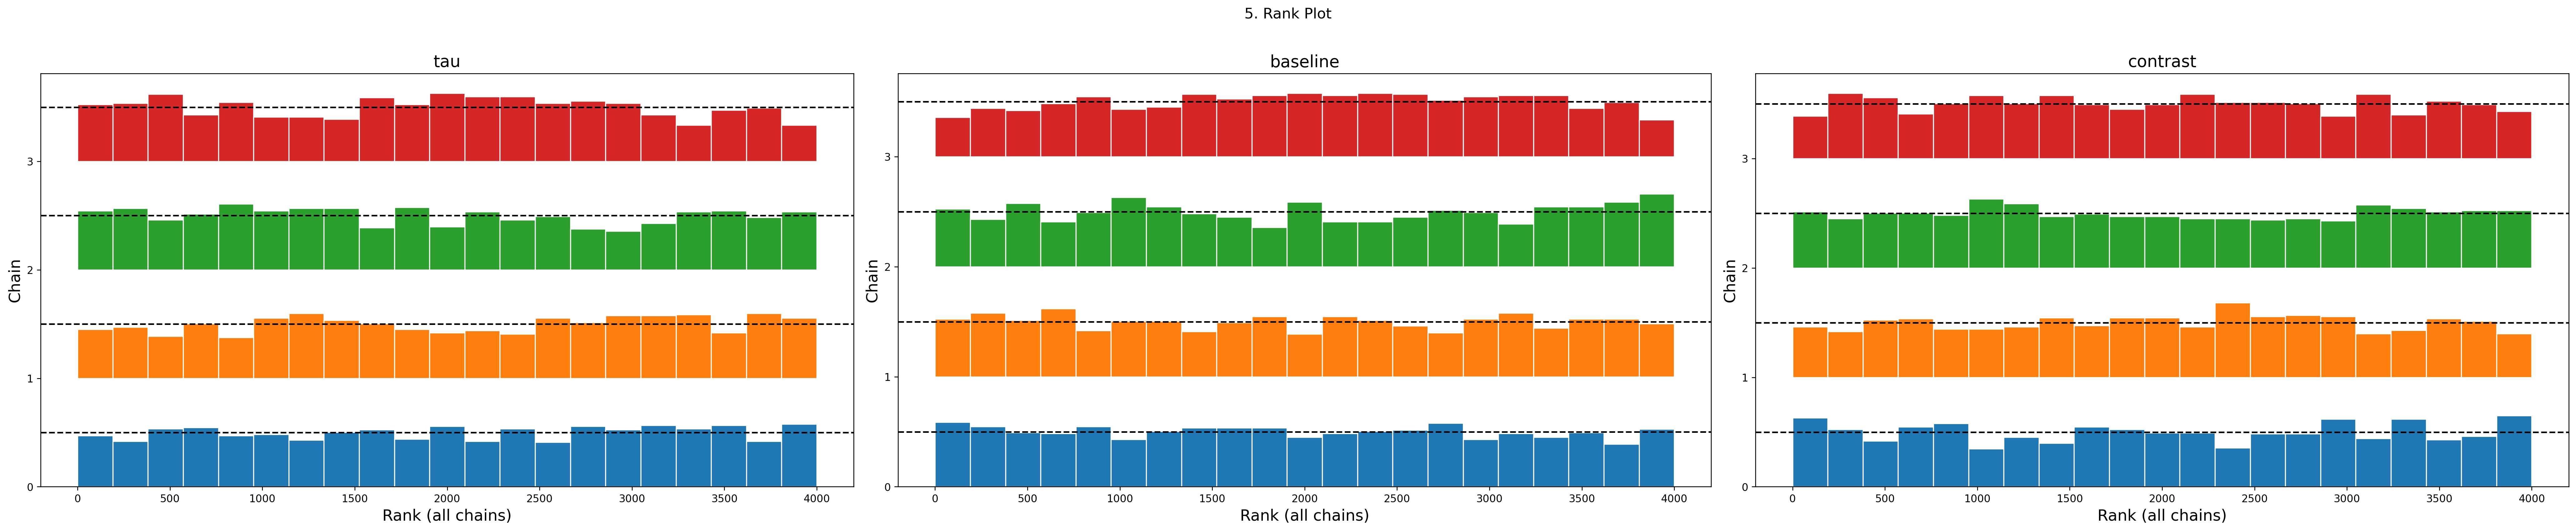

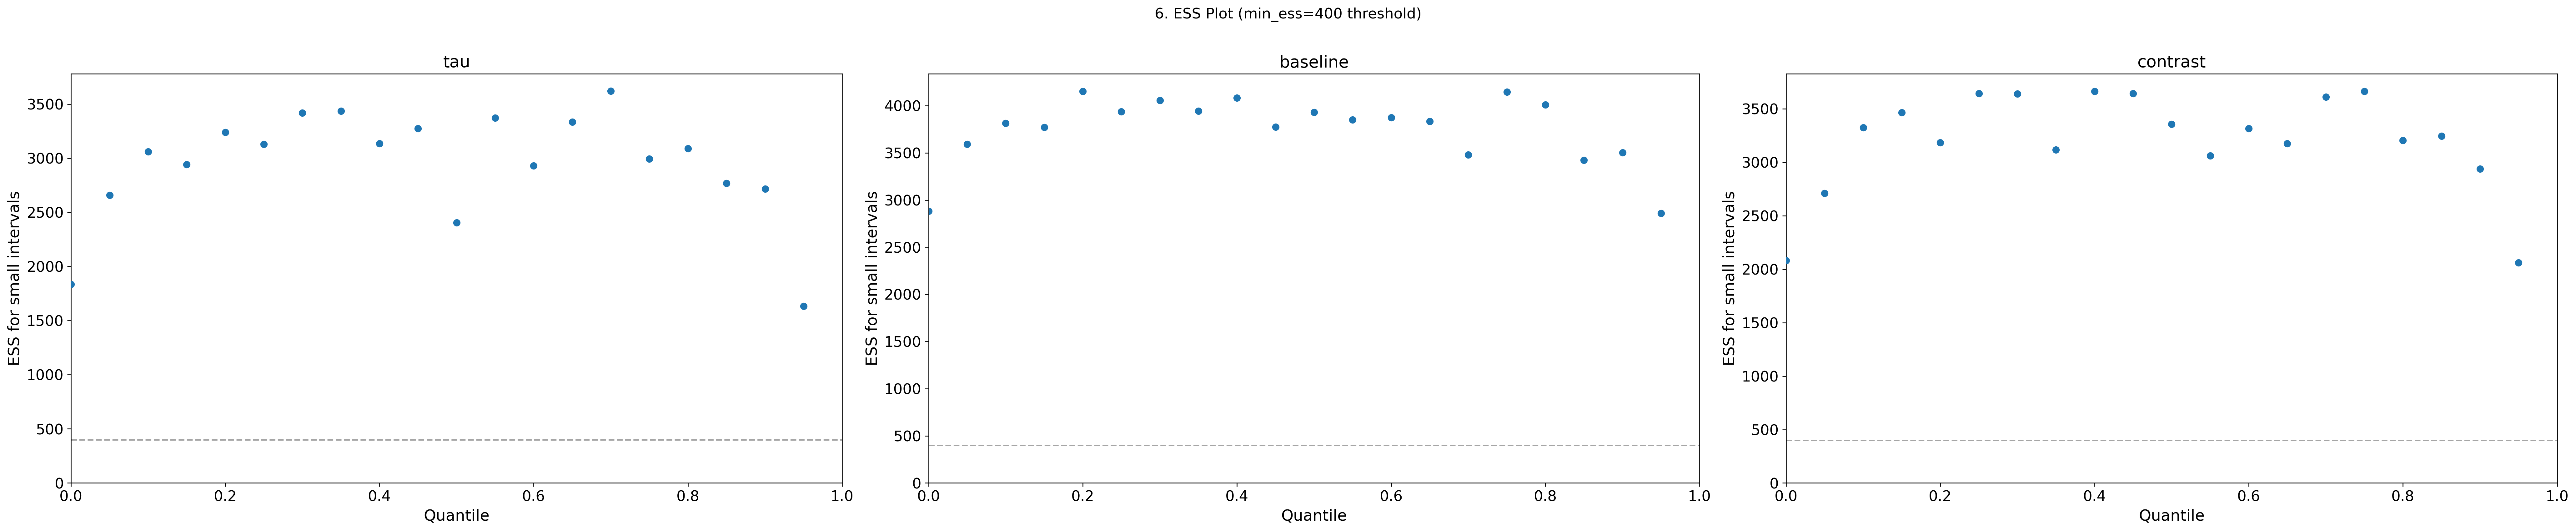

           mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau       4.911  0.075   4.773    5.051      0.002    0.001    1693.0   
baseline  1.000  0.001   0.998    1.002      0.000    0.000    2709.0   
contrast  0.300  0.001   0.297    0.302      0.000    0.000    1859.0   

          ess_tail  r_hat  
tau         1633.0    1.0  
baseline    2860.0    1.0  
contrast    2060.0    1.0  


In [10]:
if BAYES_AVAILABLE and bayes_result.arviz_data is not None:
    try:
        import arviz as az

        idata = bayes_result.arviz_data
        params = ['tau', 'baseline', 'contrast']

        # 1. Trace plot -- chains should look like "fuzzy caterpillars"
        az.plot_trace(idata, var_names=params, compact=True)
        fig = plt.gcf()
        fig.suptitle('1. Trace Plot', fontsize=14, y=1.02)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

        # 2. Pair plot -- check correlations and divergences
        az.plot_pair(idata, var_names=params, divergences=True,
                     kind='scatter', marginals=True)
        fig = plt.gcf()
        fig.suptitle('2. Pair Plot (divergences marked)', fontsize=14, y=1.02)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

        # 3. Forest plot -- credible intervals with R-hat and ESS
        az.plot_forest(idata, var_names=params, combined=True,
                       hdi_prob=0.95, r_hat=True, ess=True)
        fig = plt.gcf()
        fig.suptitle('3. Forest Plot (95% HDI)', fontsize=14, y=1.02)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

        # 4. Autocorrelation plot -- should decay to 0 quickly
        az.plot_autocorr(idata, var_names=params, combined=True)
        fig = plt.gcf()
        fig.suptitle('4. Autocorrelation Plot', fontsize=14, y=1.02)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

        # 5. Rank plot -- histograms should be roughly uniform
        az.plot_rank(idata, var_names=params)
        fig = plt.gcf()
        fig.suptitle('5. Rank Plot', fontsize=14, y=1.02)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

        # 6. ESS plot -- effective sample size across quantiles
        az.plot_ess(idata, var_names=params, kind='local', min_ess=400)
        fig = plt.gcf()
        fig.suptitle('6. ESS Plot (min_ess=400 threshold)', fontsize=14, y=1.02)
        plt.tight_layout()
        display(fig)
        plt.close(fig)

        # Summary statistics table
        print(az.summary(idata, var_names=params))

    except ImportError:
        print("Install ArviZ for diagnostic plots: pip install arviz")

## 7. Model Comparison: Single vs Double Exponential

Use AIC/BIC to determine whether a second relaxation mode is justified.

In [11]:
from xpcsviewer.fitting.models import double_exp_func

# Fit single exponential
result_single = nlsq_fit(
    model_fn=single_exp_func,
    x=t, y=g2_noise, yerr=g2_err,
    p0={"tau": 1.0, "baseline": 1.0, "contrast": 0.3},
    bounds={"tau": (1e-6, 1e6), "baseline": (0.5, 2.0), "contrast": (0, 1)},
)

# Fit double exponential
result_double = nlsq_fit(
    model_fn=double_exp_func,
    x=t, y=g2_noise, yerr=g2_err,
    p0={"tau1": 1.0, "tau2": 50.0, "baseline": 1.0,
        "contrast1": 0.2, "contrast2": 0.1},
    bounds={
        "tau1": (1e-6, 1e4), "tau2": (1e-6, 1e6),
        "baseline": (0.5, 2.0),
        "contrast1": (0, 1), "contrast2": (0, 1),
    },
)

print("Model Comparison:")
print(f"{'':>20} {'Single Exp':>14} {'Double Exp':>14}")
print(f"{'-'*50}")
print(f"{'R-squared':>20} {result_single.r_squared:>14.6f} {result_double.r_squared:>14.6f}")
print(f"{'RMSE':>20} {result_single.rmse:>14.6e} {result_double.rmse:>14.6e}")
print(f"{'AIC':>20} {result_single.aic:>14.2f} {result_double.aic:>14.2f}")
print(f"{'BIC':>20} {result_single.bic:>14.2f} {result_double.bic:>14.2f}")
print(f"{'N parameters':>20} {len(result_single.params):>14} {len(result_double.params):>14}")

preferred = 'single' if result_single.bic < result_double.bic else 'double'
delta_bic = abs(result_single.bic - result_double.bic)
print(f"\nPreferred model: {preferred} exponential (delta BIC = {delta_bic:.1f})")

if delta_bic < 2:
    print("Evidence: Weak (delta BIC < 2)")
elif delta_bic < 6:
    print("Evidence: Positive (2 < delta BIC < 6)")
elif delta_bic < 10:
    print("Evidence: Strong (6 < delta BIC < 10)")
else:
    print("Evidence: Very strong (delta BIC > 10)")

21:41:52.301 INFO     nlsq.core.minpack    | workflow='auto_global' starting: n_points=80, n_params=3
21:41:52.303 INFO     nlsq.core.minpack    | workflow='auto_global' memory budget: available=45.3GB, threshold=33.9GB, peak_estimate=0.10GB
21:41:52.303 INFO     nlsq.core.minpack    | workflow='auto_global' memory strategy: STANDARD (peak 0.10GB fits in 33.9GB)
21:41:52.303 INFO     nlsq.global_optimiza | Scale ratio 1000000x suggests CMA-ES would be beneficial, but evosax not installed. Using multi-start. Install evosax with: pip install 'nlsq[global]'
21:41:52.304 INFO     nlsq.core.minpack    | workflow='auto_global' global method: Multi-Start (n_starts=10, scale_ratio=1000000.0)
21:41:52.307 INFO     nlsq.multi_start     | Generating 10 starting points using lhs n_starts=10 | sampler=lhs | center_on_p0=True
21:41:52.315 INFO     nlsq.multi_start     | Evaluating 10 starting points
21:41:52.316 INFO     nlsq.curve_fit       | Starting curve fit n_params=3 | n_data_points=80 | metho

## 8. Comparison Plot

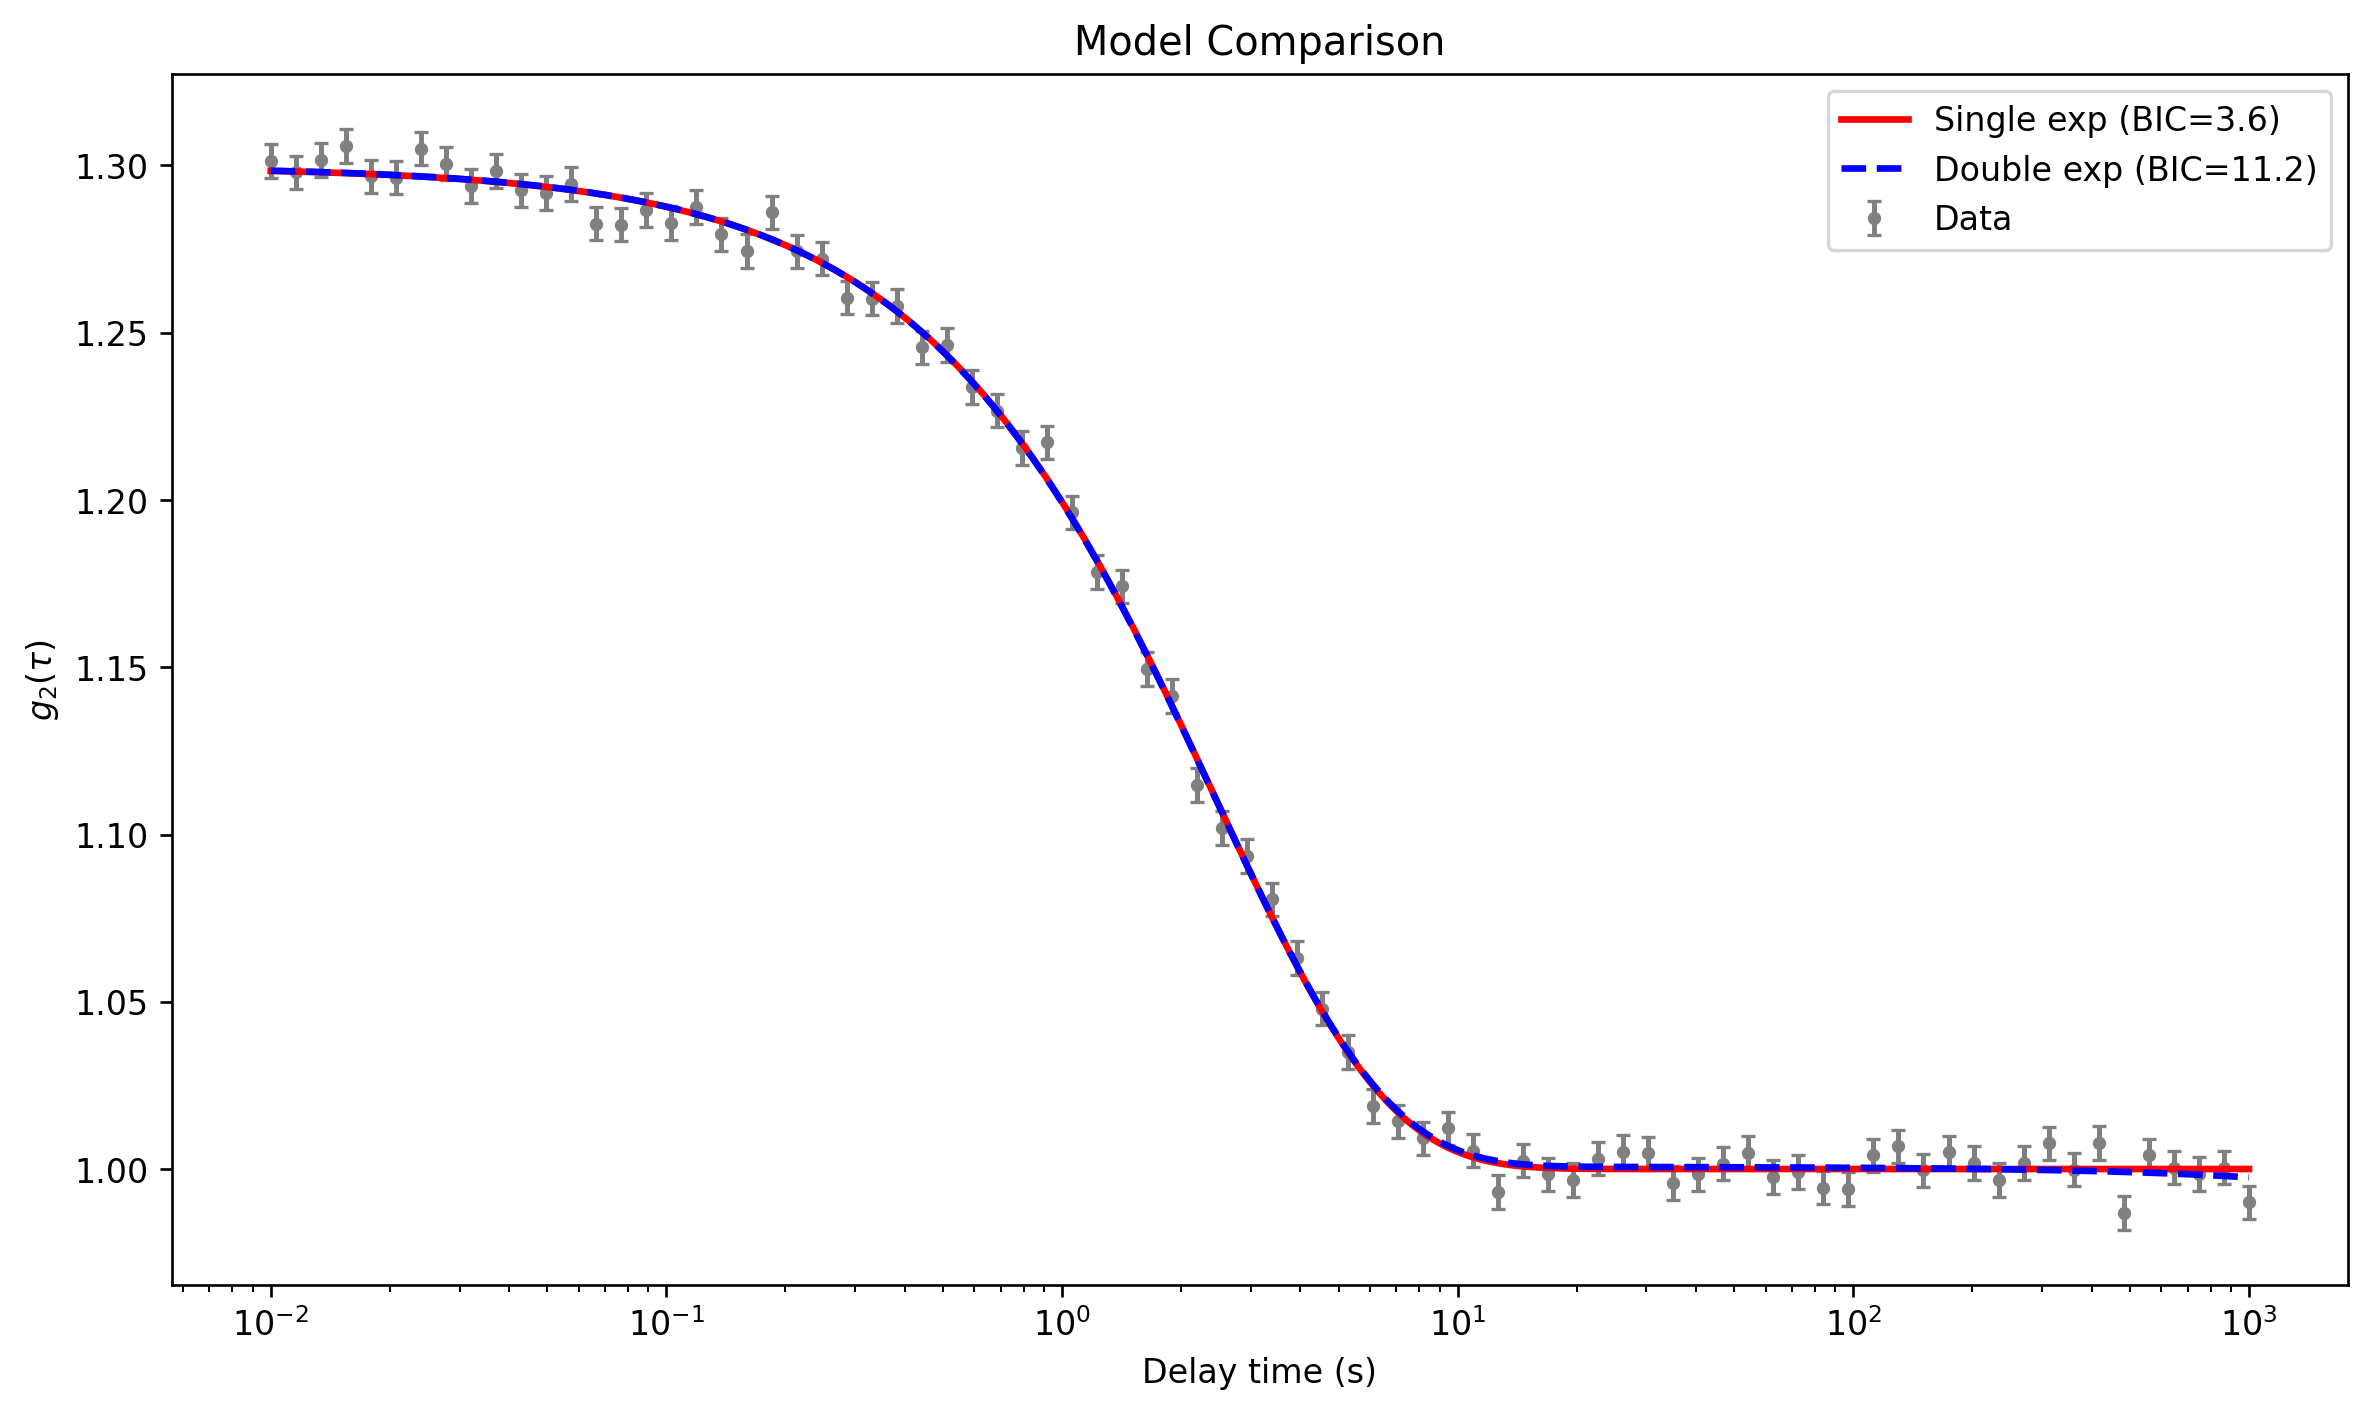

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

# Data
ax.errorbar(t, g2_noise, yerr=g2_err, fmt='o', ms=3, capsize=2,
            color='gray', label='Data', zorder=1)

# Single exp fit
g2_single = single_exp_func(
    t_fine,
    result_single.params['tau'],
    result_single.params['baseline'],
    result_single.params['contrast'],
)
ax.plot(t_fine, g2_single, 'r-', linewidth=2,
        label=f'Single exp (BIC={result_single.bic:.1f})', zorder=2)

# Double exp fit
g2_double = double_exp_func(
    t_fine,
    result_double.params['tau1'],
    result_double.params['tau2'],
    result_double.params['baseline'],
    result_double.params['contrast1'],
    result_double.params['contrast2'],
)
ax.plot(t_fine, g2_double, 'b--', linewidth=2,
        label=f'Double exp (BIC={result_double.bic:.1f})', zorder=2)

ax.set_xscale('log')
ax.set_xlabel('Delay time (s)')
ax.set_ylabel(r'$g_2(\tau)$')
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

## 9. Export Results

Save results for reproducibility.

In [13]:
import json


class NumpyEncoder(json.JSONEncoder):
    """Handle numpy/JAX types in JSON serialization."""
    def default(self, obj):
        if hasattr(obj, 'item'):  # numpy/JAX scalar
            return obj.item()
        if hasattr(obj, 'tolist'):  # numpy/JAX array
            return obj.tolist()
        return super().default(obj)


# Export NLSQ result
export_data = {
    "method": "NLSQ",
    "model": "single_exp",
    "converged": bool(nlsq_result.converged),
    "params": {k: float(v) for k, v in nlsq_result.params.items()},
    "uncertainties": {
        name: float(nlsq_result.get_param_uncertainty(name))
        for name in nlsq_result.params
    },
    "r_squared": float(nlsq_result.r_squared),
    "rmse": float(nlsq_result.rmse),
    "aic": float(nlsq_result.aic),
    "bic": float(nlsq_result.bic),
}

print(json.dumps(export_data, indent=2, cls=NumpyEncoder))

# Optionally save Bayesian result too
if BAYES_AVAILABLE:
    bayes_dict = bayes_result.to_dict()
    print(f"\nBayesian result keys: {list(bayes_dict.keys())}")
    print(f"Package versions: {bayes_dict.get('versions', {})}")

{
  "method": "NLSQ",
  "model": "single_exp",
  "converged": true,
  "params": {
    "tau": 4.913489450205446,
    "baseline": 1.0000170185556687,
    "contrast": 0.29956010410037204
  },
  "uncertainties": {
    "tau": 0.07762065977480011,
    "baseline": 0.0008589399682256384,
    "contrast": 0.0013053564277392762
  },
  "r_squared": -52.13008941867727,
  "rmse": 0.941946366104404,
  "aic": -3.5691107554561476,
  "bic": 3.576969148565496
}

Bayesian result keys: ['samples', 'nlsq_init', 'diagnostics', 'versions', 'sampler_config', 'data_metadata']
Package versions: {'xpcsviewer': 'unknown', 'numpyro': '0.20.0', 'jax': '0.8.3', 'arviz': '0.23.4', 'nlsq': '0.6.9', 'python': '3.13.7'}


## Summary

| Method | Speed | Uncertainty | When to Use |
|--------|-------|-------------|-------------|
| NLSQ (fast preset) | Very fast | Point estimates + CI | Quick exploration, batch processing |
| NLSQ (robust preset) | Fast | Point estimates + CI + diagnostics | Difficult data, initial screening |
| Bayesian NUTS | Slower | Full posterior + HDI + ArviZ | Publication results, model validation |

Key diagnostics to check:
- **NLSQ**: R-squared > 0.99, health score > 70, condition number < 1e6
- **Bayesian**: R-hat < 1.01, ESS > 400, divergences = 0, BFMI > 0.3